In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error,mean_absolute_error

In [2]:
df=pd.read_csv('Fishers maket.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 9.6 KB


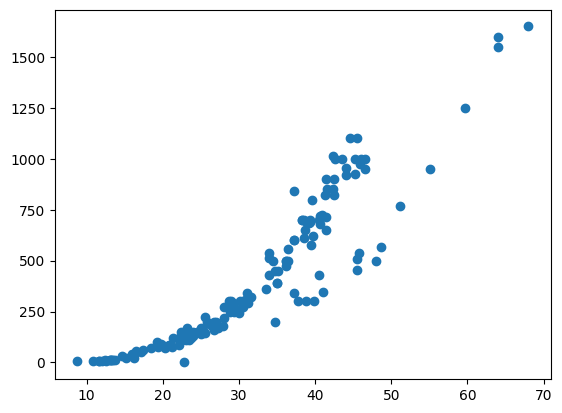

In [4]:
plt.scatter(df['Length3'], df['Weight'])

In [5]:
df.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


In [6]:
X = df[['Length3']]
y = df['Weight']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
model=LinearRegression()

In [9]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


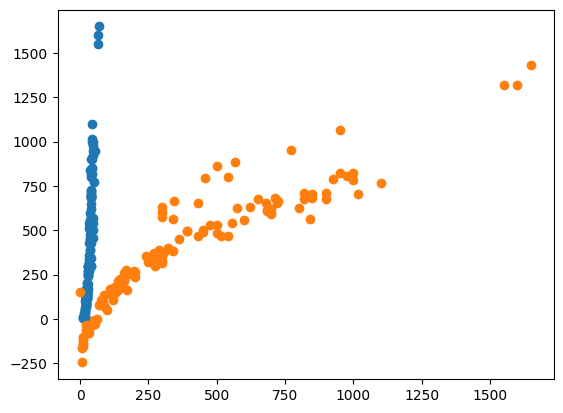

In [10]:
ypred_train=model.predict(X_train)
plt.scatter(X_train,y_train)
plt.scatter(y_train,ypred_train)

In [11]:
train_score = r2_score(y_train, ypred_train)
print(train_score)

0.8519097884403429


In [12]:
ypred_test=model.predict(X_test)

In [13]:
test_score = r2_score(y_test, ypred_test)
print(test_score)

0.8464891636131897


In [14]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=4)
updated_xtrain=poly.fit_transform(X_train)
updated_xtest=poly.transform(X_test)

In [15]:
updated_xtrain


array([[1.00000000e+00, 1.72000000e+01, 2.95840000e+02, 5.08844800e+03,
        8.75213056e+04],
       [1.00000000e+00, 4.87000000e+01, 2.37169000e+03, 1.15501303e+05,
        5.62491346e+06],
       [1.00000000e+00, 3.11000000e+01, 9.67210000e+02, 3.00802310e+04,
        9.35495184e+05],
       [1.00000000e+00, 2.35000000e+01, 5.52250000e+02, 1.29778750e+04,
        3.04980062e+05],
       [1.00000000e+00, 2.53000000e+01, 6.40090000e+02, 1.61942770e+04,
        4.09715208e+05],
       [1.00000000e+00, 2.37000000e+01, 5.61690000e+02, 1.33120530e+04,
        3.15495656e+05],
       [1.00000000e+00, 2.41000000e+01, 5.80810000e+02, 1.39975210e+04,
        3.37340256e+05],
       [1.00000000e+00, 4.13000000e+01, 1.70569000e+03, 7.04449970e+04,
        2.90937838e+06],
       [1.00000000e+00, 4.06000000e+01, 1.64836000e+03, 6.69234160e+04,
        2.71709069e+06],
       [1.00000000e+00, 4.80000000e+01, 2.30400000e+03, 1.10592000e+05,
        5.30841600e+06],
       [1.00000000e+00, 1.1600

In [16]:
model=LinearRegression()
model.fit(updated_xtrain,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


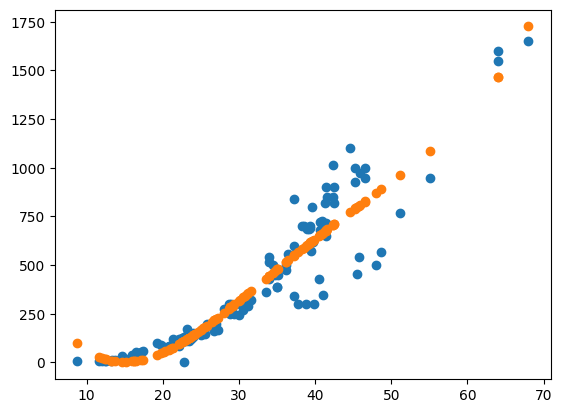

In [17]:
y_pred_train=model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],y_train)
plt.scatter(updated_xtrain[:,1],y_pred_train)

In [18]:
#Train score
train_score=r2_score(y_train,y_pred_train)
print(f"Train score : {train_score}")

Train score : 0.8856496868844017


In [19]:
#Test score
y_pred_test=model.predict(updated_xtest)
test_score=r2_score(y_test,y_pred_test)
print(f"Test score : {test_score}")

Test score : 0.8812441993635196


### degree=2

#### Train score : 0.8756695367609073 Test score : 0.8664863426509607

### degree=3

#### Train score : 0.8805809992691505 Test score : 0.8862094896219262

### degree=4

#### Train score : 0.8856496868844017 Test score : 0.8812441993635196

In [20]:
r2 = r2_score(y_test, y_pred_test)
print("R2 Score:", r2)

R2 Score: 0.8812441993635196


In [21]:
mae = mean_absolute_error(y_test, y_pred_test)
print("MAE:", mae)


MAE: 84.35990253857527


In [22]:
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("RMSE:", rmse)

RMSE: 129.96822838741681
